# Predicción de ventas netas

### Ventas - devolciones por cada día

In [1]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



 FASE FINAL: INTEGRACIÓN DE CAJA NETA MULTI-MODELO 

 Procesando Flujo de Caja para: Regresion_Multilineal...


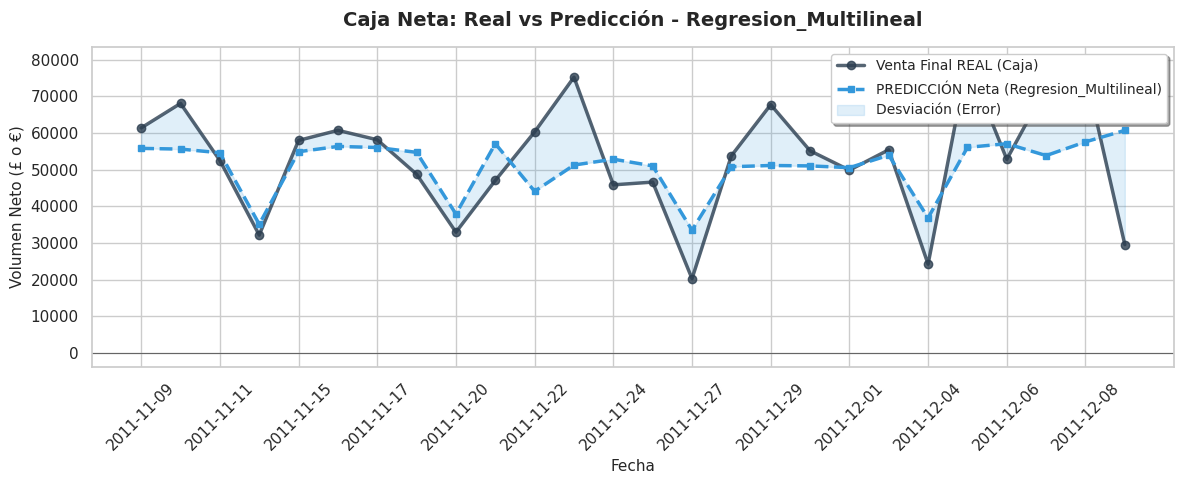


 Procesando Flujo de Caja para: Regresion_Polinomica_(Grado_2)...


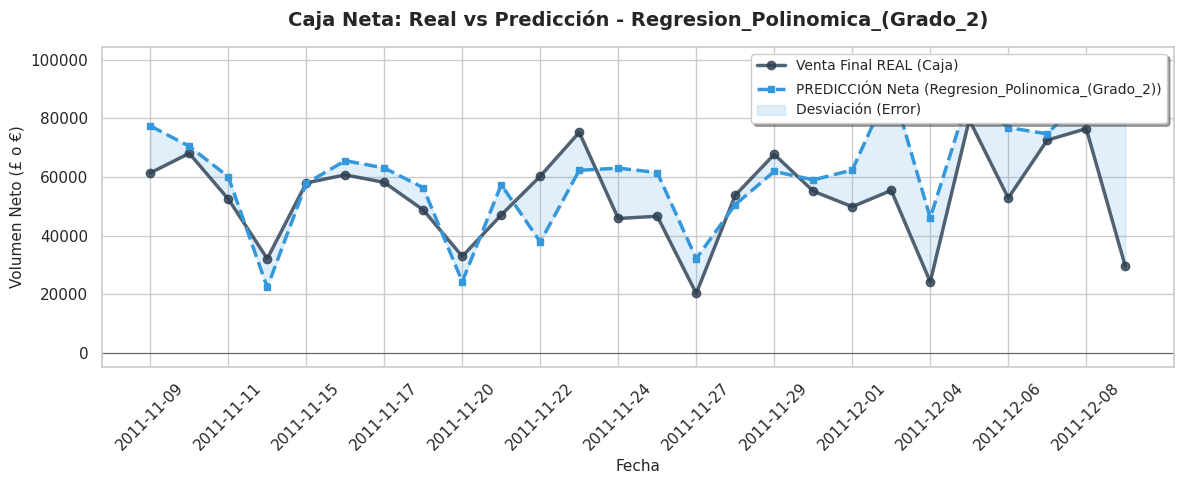


 Procesando Flujo de Caja para: Arbol_de_Decision...


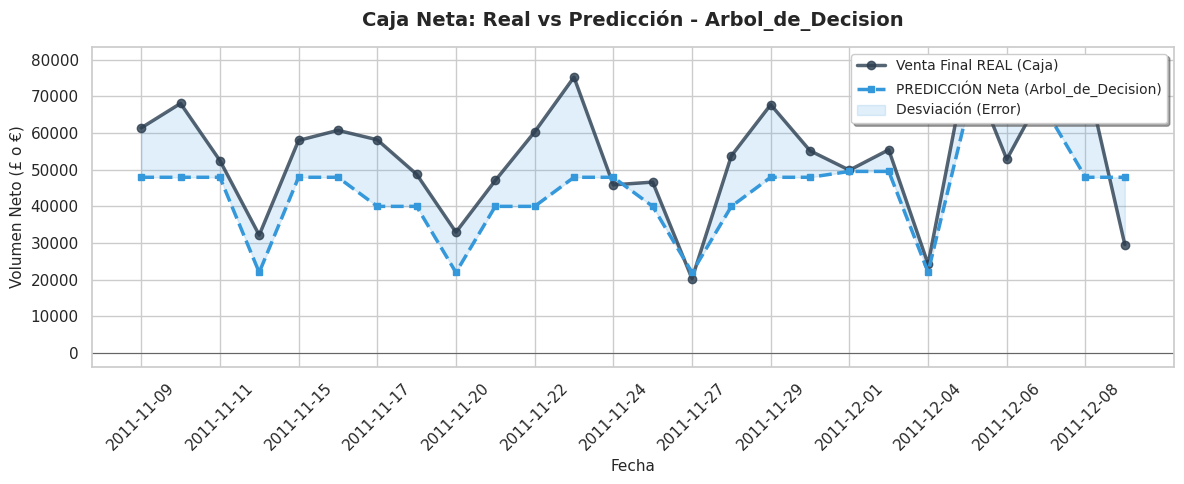


 Procesando Flujo de Caja para: XGBoost...


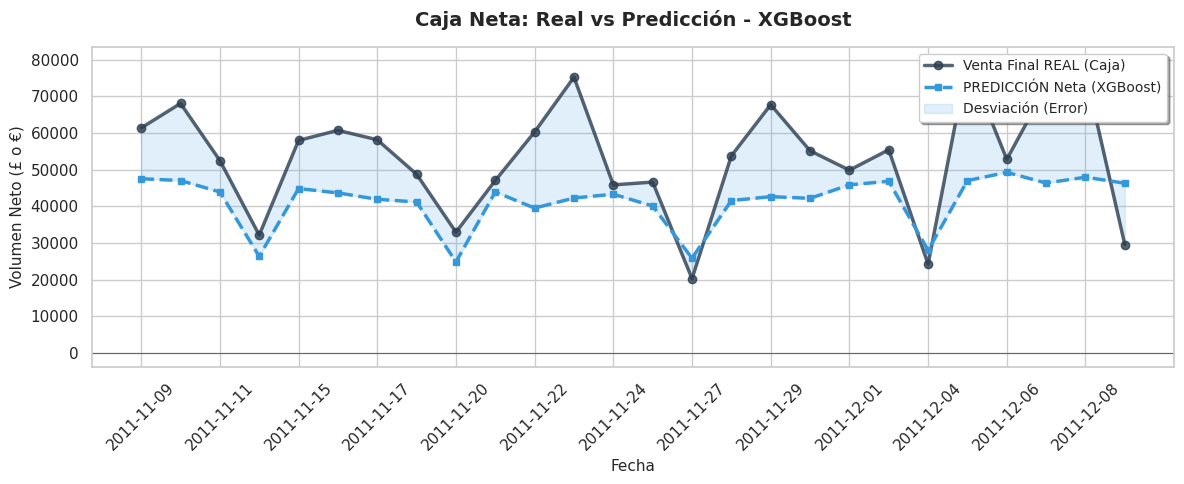


 RANKING DEFINITIVO: PRECISIÓN EN EL FLUJO DE CAJA NETO 


,Modelo,MAE Neto (£),RMSE Neto (£),R2 Neto
0,Regresion_Multilineal,9758.10,12696.95,0.33
2,Arbol_de_Decision,11686.41,13866.09,0.20
3,XGBoost,13751.53,16544.79,-0.13
1,Regresion_Polinomica_(Grado_2),13539.76,19347.94,-0.55


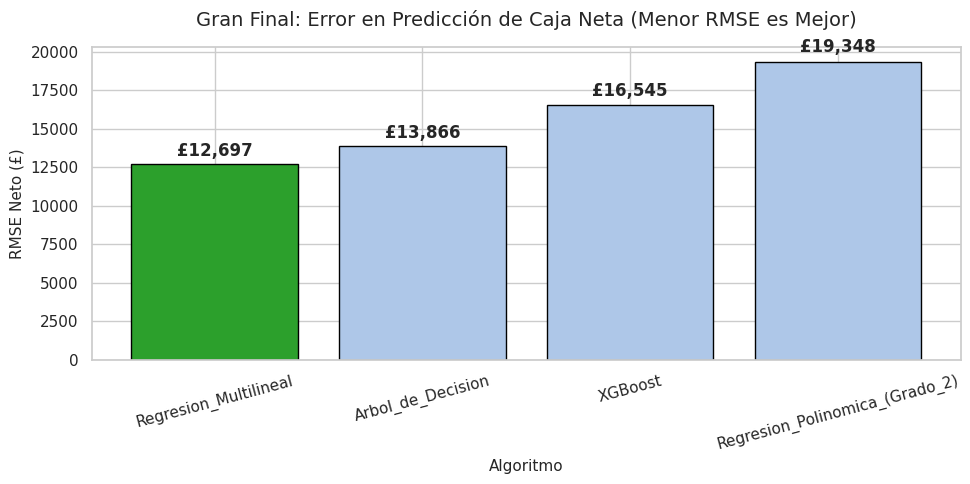

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

# Asegúrate de haber montado el drive antes:
# from google.colab import drive
# drive.mount('/content/drive')

print("\n" + "="*80)
print(" FASE FINAL: INTEGRACIÓN DE CAJA NETA MULTI-MODELO ")
print("="*80)

# Lista de los modelos que hemos ido guardando
# (Añade "Random Forest" a la lista si también guardaste sus CSVs con el mismo formato)
nombres_modelos = [
    "Regresion_Multilineal",
    "Regresion_Polinomica_(Grado_2)",
    "Arbol_de_Decision",
    "XGBoost"
]

resultados_caja_neta = []

for nombre in nombres_modelos:
    # Reconstruimos el nombre exacto de los archivos en Drive
    nombre_archivo = nombre.replace(" ", "_").replace("ó", "o").replace("í", "i").replace("Á", "A")
    ruta_ventas = f'/content/drive/MyDrive/TFM_Prediccion_Ventas_{nombre_archivo}.csv'
    ruta_devolu = f'/content/drive/MyDrive/TFM_Prediccion_Devolu_{nombre_archivo}.csv'

    # Verificamos que los archivos existan antes de intentar abrirlos
    if not os.path.exists(ruta_ventas) or not os.path.exists(ruta_devolu):
        print(f"No se encontraron los CSVs para '{nombre}'. Saltando...")
        continue

    print(f"\n Procesando Flujo de Caja para: {nombre}...")

    # 2. Cargar los CSVs
    ventas_test = pd.read_csv(ruta_ventas)
    devoluc_test = pd.read_csv(ruta_devolu)

    # 3. Unir por fecha (Merge) y Calcular la Caja Neta
    df_mes_objetivo = pd.merge(ventas_test, devoluc_test, on='date')

    # Real: Ventas reales - Devoluciones reales
    df_mes_objetivo['real_final_sales'] = df_mes_objetivo['actual_sales'] - df_mes_objetivo['actual_returns']

    # Predicción: Ventas predichas - Devoluciones predichas
    df_mes_objetivo['predicted_final_sales'] = df_mes_objetivo['predicted_sales'] - df_mes_objetivo['predicted_returns']

    # 4. Calcular métricas DEFINITIVAS (Sobre el dinero limpio en caja)
    mae = mean_absolute_error(df_mes_objetivo['real_final_sales'], df_mes_objetivo['predicted_final_sales'])
    rmse = np.sqrt(mean_squared_error(df_mes_objetivo['real_final_sales'], df_mes_objetivo['predicted_final_sales']))
    r2 = r2_score(df_mes_objetivo['real_final_sales'], df_mes_objetivo['predicted_final_sales'])

    resultados_caja_neta.append({
        "Modelo": nombre,
        "MAE Neto (£)": mae,
        "RMSE Neto (£)": rmse,
        "R2 Neto": r2
    })


    # VISUALIZACIÓN PROFESIONAL

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 5))

    # Línea Real
    plt.plot(df_mes_objetivo['date'], df_mes_objetivo['real_final_sales'],
             label='Venta Final REAL (Caja)', color='#2C3E50',
             linewidth=2.5, marker='o', markersize=6, alpha=0.8)

    # Línea de Predicción
    plt.plot(df_mes_objetivo['date'], df_mes_objetivo['predicted_final_sales'],
             label=f'PREDICCIÓN Neta ({nombre})', color='#3498DB',
             linewidth=2.5, linestyle='--', marker='s', markersize=4)

    # Sombreado de error
    plt.fill_between(df_mes_objetivo['date'],
                     df_mes_objetivo['real_final_sales'],
                     df_mes_objetivo['predicted_final_sales'],
                     color='#3498DB', alpha=0.15, label='Desviación (Error)')

    plt.title(f'Caja Neta: Real vs Predicción - {nombre}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Fecha', fontsize=11)
    plt.ylabel('Volumen Neto (£ o €)', fontsize=11)

    # Mejora visual de las fechas en el eje X
    plt.xticks(np.arange(0, len(df_mes_objetivo['date']), step=2), rotation=45)

    plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=10)
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    plt.tight_layout()
    plt.show()


# 6. TABLA Y GRÁFICO COMPARATIVO FINAL

# Convertimos y ordenamos por el error RMSE
df_res_netos = pd.DataFrame(resultados_caja_neta).sort_values(by="RMSE Neto (£)", ascending=True)

print("\n" + "="*80)
print(" RANKING DEFINITIVO: PRECISIÓN EN EL FLUJO DE CAJA NETO ")
print("="*80)
display(df_res_netos.round(2))

# Gráfico de barras resumen del proyecto
plt.figure(figsize=(10, 5))
colores = ['#2ca02c' if i == 0 else '#aec7e8' for i in range(len(df_res_netos))]
barras = plt.bar(df_res_netos['Modelo'], df_res_netos['RMSE Neto (£)'], color=colores, edgecolor='black')

plt.title("Gran Final: Error en Predicción de Caja Neta (Menor RMSE es Mejor)", fontsize=14, pad=15)
plt.ylabel("RMSE Neto (£)", fontsize=11)
plt.xlabel("Algoritmo", fontsize=11)
plt.xticks(rotation=15)

for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + (yval*0.02), f'£{yval:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()